# ГП-4.2. Проверка гипотез методами математической статистики

## Часть 1. Постановка задачи и выбор датасета

К нашей команде пришёл университет, который хочет внедрить инструмент, в будущем позволяющий отслеживать студентов, у которых потенциально могут появиться проблемы с обучением. Наша задача - найти датасет, провести EDA, выявить и протестировать гипотезы, которые позволят выявлять студентов из группы риска.

Бизнес-заказчик: Администрация университета / служба академической поддержки студентов.

Бизнес-цель: Снизить уровень отчислений за счет раннего выявления студентов группы риска и более точного распределения мер академической и финансовой поддержки.

По условию датасет должен быть выбран на сайте https://archive.ics.uci.edu/, также в нём должно быть как минимум 2000 записей и 8 признаков.

Наш выбор - датасет https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success, данный датасет включает почти четыре с половиной тысячи записей и целых 36 признаков.

Датасет **«Predict Students' Dropout and Academic Success»** взят с UCI Machine Learning Repository. Он содержит реальные данные о **4424 студентах** одного португальского высшего учебного заведения. 

Данные собирались в рамках национального проекта по борьбе с отчислениями и академической неуспеваемостью. Информация была взята из нескольких разных внутренних систем университета (академическая база, система управления обучением, данные приёмной комиссии и т.д), а также дополнена макроэкономическими показателями из открытых источников. 

Период поступления студентов - с 2008 по 2019 год. 

Цель создания датасета - научиться заранее выявлять студентов, которые находятся в зоне риска отчисления, чтобы университет мог вовремя оказывать им поддержку.

## Часть 2. Подготовка окружения

In [2]:
! pip install pandas
! pip install numpy
! pip install seaborn matplotlib

In [3]:
! python -m pip install seaborn matplotlib --upgrade

In [4]:
import sys
!{sys.executable} -m pip install seaborn matplotlib --upgrade --force-reinstall

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached numpy-2.4.6-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using c

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('data.csv', sep=';')

## Часть 3. EDA

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

Как мы видим, признаки можно разделить по группам: демографические и социальные (национальность, семейное положение, гендер, возраст, место жительства и так далее), финансовые (стипендии, плата за обучения, долги), выбор программы обучения (специальность, номер по предпочтению, формат обучения), образовательный "бэкграунд" (информация об обучении родителей, баллы при поступлении, предыдущая квалификация), академическая успеваемость (всё, что связано с оценками) и макроэкономические показатели (безработица, инфляция и ВВП).

### Наиболее интересные признаки

| №  | Признак                                      | Тип признака       | Что это |
|----|----------------------------------------------|--------------------|--------|
| 1  | Curricular units 2nd sem (approved)          | Академический      | Количество сданных предметов во 2-м семестре |
| 2  | Curricular units 2nd sem (grade)             | Академический      | Средний балл во 2-м семестре |
| 3  | Curricular units 1st sem (approved)          | Академический      | Количество сданных предметов в 1-м семестре |
| 4  | Curricular units 1st sem (grade)             | Академический      | Средний балл в 1-м семестре |
| 5  | Age at enrollment                            | Демографический    | Возраст студента при поступлении |
| 6  | Debtor                                       | Финансовый         | Наличие задолженностей (долгов) |
| 7  | Tuition fees up to date                      | Финансовый         | Оплата обучения вовремя (без просрочек) |
| 8  | Scholarship holder                           | Финансовый         | Получение стипендии |
| 9  | Gender                                       | Демографический    | Пол студента (0 — женский, 1 — мужской) |
| 10 | Admission grade                              | Академический      | Балл при поступлении |
| 11 | Displaced                                    | Географический     | Переезд из другого региона |
| 12 | Application mode                             | Поступление        | Способ подачи заявления на поступление |

Теперь, после того как мы верхнеуровнего познакомились с нашим датасетом, попробуем посмотреть, насколько он "чистый". Проверим количество повторов

In [9]:
df.duplicated().sum()
df.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

Видим, что прямых дубликатов ожидаемо нет, как и пропусков. Ну, так как мы скачили со специализированного сайта наш датасет, это вполне логично. 

### Проведение FE

Для того, чтобы в дальнейшем иметь возможность просмотреть больше интересных фактов при проведении EDA - проведём Feature Engineering и создадим следующие признаки:

| № | Название признака          | Тип            | Как создан                                                                 | Для чего создан |
|---|---------------------------|----------------|-----------------------------------------------------------------------------|-----------------|
| 1 | `delta_curricular`          | числовой       | `Curricular units 2nd sem (approved)` - `Curricular units 1st sem (approved)` | Показывает изменение количества сданных предметов между первым и вторым семестром |
| 2 | `academic_kategory`     | категориальный | Decline (<= −1), Stable (-0,5…0,5), improve (>= 1)                         | Категоризация динамики успеваемости студента |
| 3 | `financial_state`        | числовой (0–2) | `Debtor` + (1 - `Tuition fees up to date`)                      |   Агрегированный показатель финансовой нагрузки на студента  |
| 4 | `is_adult_learner`           | бинарный       | 1, если `Age at enrollment` >= 23                                            | Выделение группы взрослых студентов |
| 5 | `first_gen`        | бинарный       | 1, если у обоих родителей нет высшего образования                           | студент первого поколения|

In [9]:
df['delta_curricular'] = (
    df['Curricular units 2nd sem (approved)'] - 
    df['Curricular units 1st sem (approved)']
)

In [12]:
def get_kategory(delta):
    if delta <= -1:
        return 'Decline'
    elif delta >= 1:
        return 'Improve'
    else:
        return 'Stable'

df['delta_curricular'] = df['delta_curricular'].apply(get_kategory)

In [13]:
df['financial_state'] = df['Debtor'] + (1 - df['Tuition fees up to date'])

In [14]:
df['is_adult_learner'] = (df['Age at enrollment'] >= 23).astype(int)

In [15]:
codes = [2, 3, 4, 5, 6, 40, 41, 42, 43, 44]

In [16]:
mother_higher = df["Mother's qualification"].isin(codes)
father_higher = df["Father's qualification"].isin(codes)

In [17]:
df['first_gen'] = ((mother_higher) & (father_higher)).astype(int)

### Смотрим на корреляции

Теперь посмотрим, а насколько признаки зависят друг от друга. Для этого будем использовать такой параметр как корреляция. Это позволит нам убрать признаки, которые нам вообще не интересны и понять верхнеуровнево, какие зависимости в первую очередь являются ключевыми и более очевидными. Однако тут главное не переборщить с "откидыванием" признаков, так как часть может быть очень даже полезна в дальнейшем, хотя на данный момент корреляций мы не видим.

In [18]:
numeric_df = df.select_dtypes(include=[np.number])

In [8]:
corr_matrix = numeric_df.corr()

In [9]:
corr_matrix

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
Marital status,1.000000,0.264006,-0.125854,0.046365,-0.274939,0.062529,-0.022406,-0.008843,0.193163,0.130353,...,0.034711,0.062831,0.039026,0.022784,-0.043739,-0.071506,0.020426,-0.020338,0.008761,-0.027003
Application mode,0.264006,1.000000,-0.286357,0.065385,-0.304092,0.422411,-0.039020,-0.000661,0.118974,0.083276,...,0.045828,0.238445,0.130046,0.167872,-0.071526,-0.115424,0.047983,0.089080,-0.016375,-0.022743
Application order,-0.125854,-0.286357,1.000000,0.059507,0.158657,-0.184315,-0.064484,-0.022416,-0.064956,-0.050288,...,-0.031699,-0.125815,0.028878,-0.055089,0.071793,0.055517,-0.015757,-0.098419,-0.011133,0.030201
Course,0.046365,0.065385,0.059507,1.000000,-0.043151,0.006654,-0.081013,-0.033923,0.054543,0.050724,...,0.034514,-0.089817,0.401539,0.278797,0.198032,0.348728,0.030816,0.007153,0.017710,-0.020265
Daytime/evening attendance\t,-0.274939,-0.304092,0.158657,-0.043151,1.000000,-0.071871,0.052597,0.018530,-0.204767,-0.139894,...,0.045630,-0.111953,0.000371,0.014610,0.034022,0.050493,-0.004229,0.061974,-0.024043,0.022929
Previous qualification,0.062529,0.422411,-0.184315,0.006654,-0.071871,1.000000,0.104072,-0.029214,-0.013190,-0.006614,...,0.002887,0.143031,0.056179,0.114850,-0.008632,0.000942,0.005102,0.111958,-0.063736,0.064069
Previous qualification (grade),-0.022406,-0.039020,-0.064484,-0.081013,0.052597,0.104072,1.000000,0.054088,-0.060670,-0.035234,...,-0.003926,-0.018489,-0.031649,-0.061355,0.050263,0.053239,-0.019015,0.045222,0.018710,-0.052620
Nacionality,-0.008843,-0.000661,-0.022416,-0.033923,0.018530,-0.029214,0.054088,1.000000,-0.049946,-0.085282,...,0.009145,-0.007278,-0.020113,-0.025721,-0.017880,-0.008497,-0.014041,-0.000651,-0.008922,0.034478
Mother's qualification,0.193163,0.118974,-0.064956,0.054543,-0.204767,-0.013190,-0.060670,-0.049946,1.000000,0.535140,...,0.003183,0.042771,0.035150,0.021033,-0.014858,-0.031175,0.021305,-0.114351,0.059441,-0.083657
Father's qualification,0.130353,0.083276,-0.050288,0.050724,-0.139894,-0.006614,-0.035234,-0.085282,0.535140,1.000000,...,-0.017333,0.042666,0.024380,0.009514,0.005285,-0.008083,-0.007430,-0.077905,0.057633,-0.071610


Итак, мы получили матрицу корреляций. Но, конечно, в таком формате на неё смотреть вообще не удобно. Для того, чтобы сориентироваться, построим график, на котором посмотрим с цветовым сопровождением, где зависимости сильные.

c:\Users\artem.moshenko\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\artem.moshenko\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


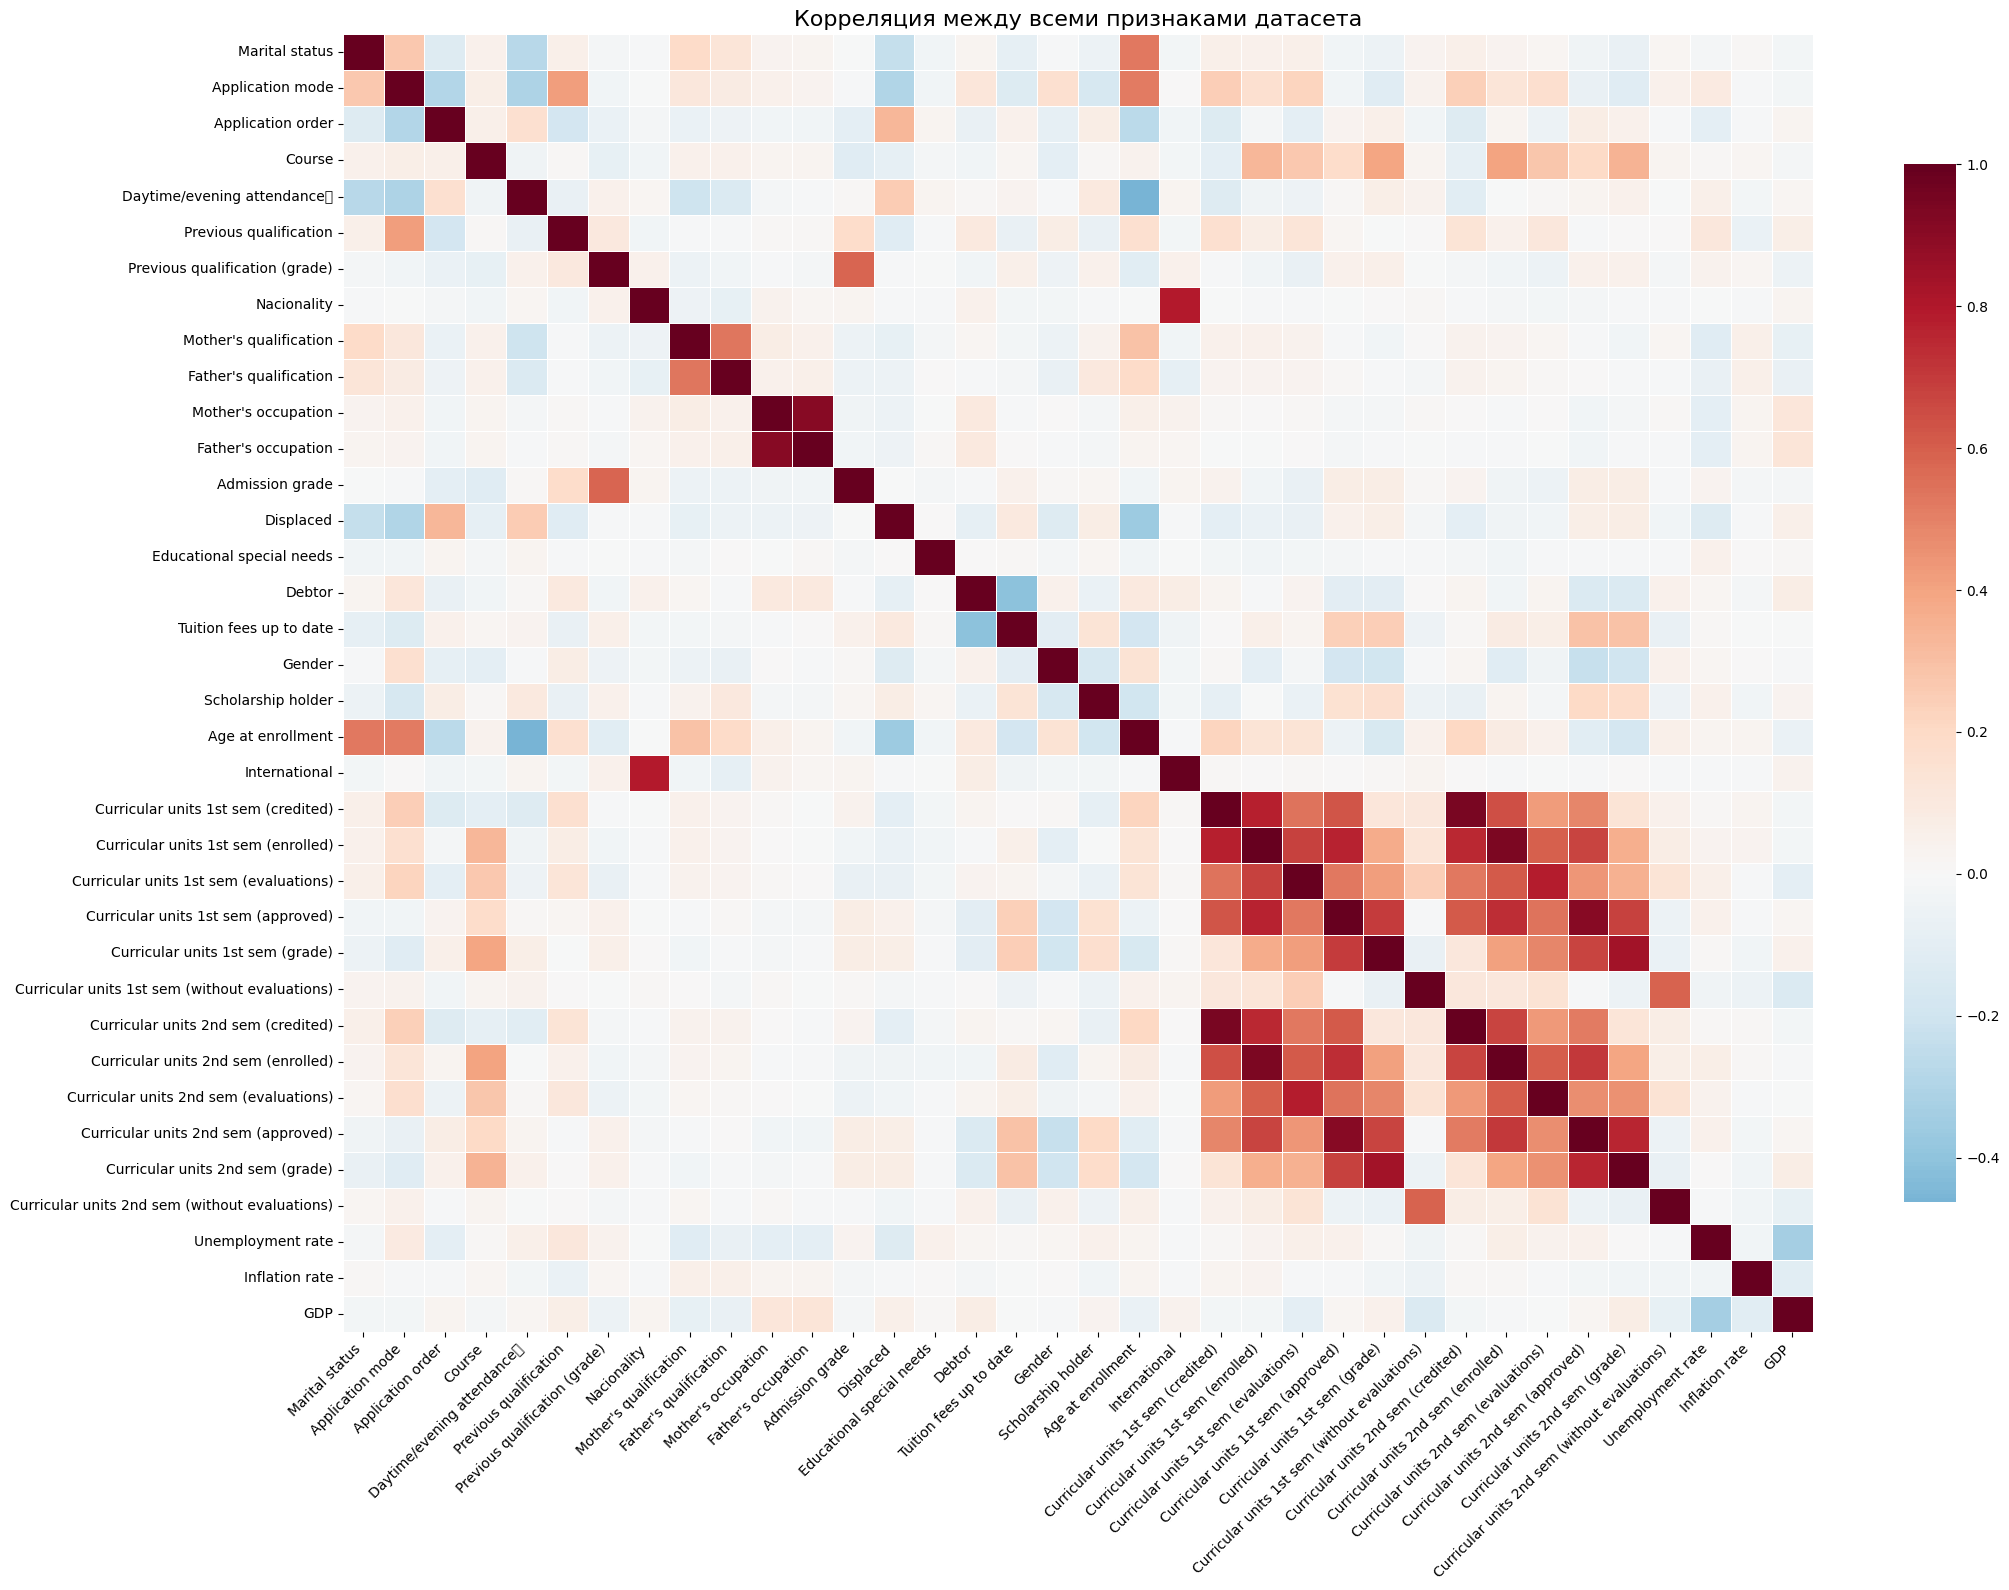

In [10]:
plt.figure(figsize=(22, 16))

sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title('Корреляция между всеми признаками датасета', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Как мы видим, сильнее всего коррелирует успеваемость. Это и понятно, оценки за 1 семестр сильно предсказывают оценки за второй: зачётные единицы, записанные единицы, количество оценок и их характер (плохо ли учится студент или хорошо). 

Помимо этого финансовая грамотность также является достаточно весомым фактором. Люди без финансовых долгов чаще учатся хорошо.

Очень явно просматривается корреляция (причём отрицательная! это просто потому что так распределелилась буллиана вечернего/утреннего обучения, 1 - дневное, 0 - вечернее) между возрастом человека при поступлении и вариантом программы обучения. Логично, что чем старше человек, тем вероятнее что он работает и хочет проходить обучение уже после своей деятельности.

Также очень любопытно, оставаясь на возрасте, наблюдать, что чем старше человек, тем меньше вероятность, что он приехал их другого региона. Ну и административные дела, чем старше студент (например он уже взрослый), тем больше вероятность что он будет поступать не по первой волне и порядковый номер предпочитаемого курса будет выше.

Ещё при поступлении видим интересную корреляцию - чем выше при поступлении у человека балл, тем выше у него опыта до поступления было. Что логично, чтобы хорошо написать экзамен нужно много учиться и работать.

Говорить про связь internation и nacionality не будем, тут и так всё очевидно. Если у человека иностранная национальность, то он иностранный студент. Это скорее своеборазная проверка правильности графика.

А вот из малозаметных, но интересных деталей - оценка за второй семестр выше у девушек (возможно их просто больше, далее это проверим). И сюда же отнесём, что если человек платит за обучение, то у него больше шансов получить хорошую оценку. Тот же принцип - предполагаем, что просто платных мест больше, поэтому так и происходит.

In [11]:
df['Gender'].value_counts()

Gender
0    2868
1    1556
Name: count, dtype: int64

И вот тут стоит сказать, что 0 - это девушки, а 1 - это парни. Как видим, девушек и правда в два раза больше, так что это вообще не корреляция а просто количество студентов.

In [12]:
df['Tuition fees up to date'].value_counts()

Tuition fees up to date
1    3896
0     528
Name: count, dtype: int64

Ну и то же самое с платниками и бюджетниками. Никакой нет корреляции, просто студентов 1 (оплата обучения актуальна) намного больше, чем 0 (оплата обучения не актуальна)

Ну и посмотрим на цифры более детально, посчитаем корреляцию с таргетом

In [13]:
target_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}

In [14]:
df['Target_num'] = df['Target'].map(target_map)

In [15]:
only_num = df.select_dtypes(include=[np.number]).columns.tolist()

In [16]:
corr_with_target = df[only_num].corr()['Target_num'].sort_values(ascending=False)
corr_with_target = corr_with_target.drop('Target_num')

In [17]:
corr_with_target.head(15)

Curricular units 2nd sem (approved)       0.624157
Curricular units 2nd sem (grade)          0.566827
Curricular units 1st sem (approved)       0.529123
Curricular units 1st sem (grade)          0.485207
Tuition fees up to date                   0.409827
Scholarship holder                        0.297595
Curricular units 2nd sem (enrolled)       0.175847
Curricular units 1st sem (enrolled)       0.155974
Admission grade                           0.120889
Displaced                                 0.113986
Previous qualification (grade)            0.103764
Curricular units 2nd sem (evaluations)    0.092721
Application order                         0.089791
Daytime/evening attendance\t              0.075107
Curricular units 2nd sem (credited)       0.054004
Name: Target_num, dtype: float64

### Распределение студентов по статусу

Теперь более детально изучим конкретные признаки. Начнём того, который прямо даёт нам понять судьбу студента - статус. Всего в датасете есть 3 статуса: отчислился, учится, выпустился. Давайте посмотрим распределение таких в датасете

In [18]:
target_counts = df['Target'].value_counts()

In [19]:
target_counts

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Теперь для визуализации и дальнейшего упрощения посмтроим небольшую круговую диаграмму с распределением цветов

In [20]:
colors = [ '#2ca02c', '#d62728', '#1f77b4']  # красный, синий, зелёный

Зелёный цвет - студент выпустился

Синий цвет - студент продолжает учиться

Красный цвет - студент отчислился

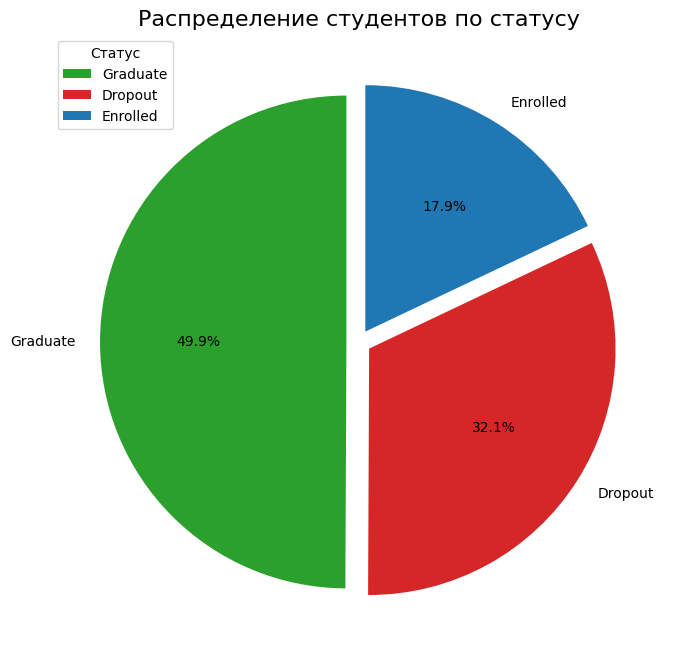

In [21]:
plt.figure(figsize=(8, 8))
plt.pie(target_counts, 
        labels=target_counts.index,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        explode=(0.05, 0.05, 0.05))

plt.title('Распределение студентов по статусу', fontsize=16)

plt.legend(title='Статус')
plt.show()

Видим, что половина датасета - это уже выпускники, около 30% отчислились и всего лишь 18 процетов продолжает обучение. На самом деле, с точки зрения машинного обучения, достаточно хорошая картина.

### Возраст при поступлении студента и его дальнейшая судьба

C:\Users\artem.moshenko\AppData\Local\Temp\ipykernel_26132\2916512599.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target', y='Age at enrollment', palette= {'Dropout': 'red', 'Enrolled': 'blue', 'Graduate': 'green'})


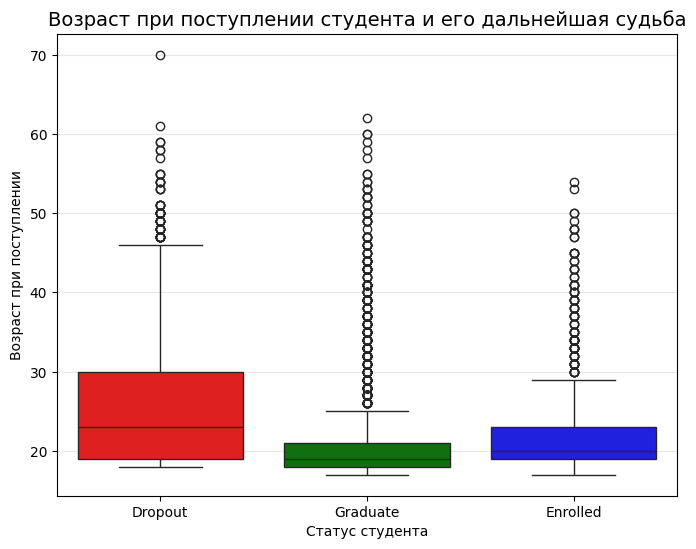

In [22]:
plt.figure(figsize=(8, 6))

sns.boxplot(data=df, x='Target', y='Age at enrollment', palette= {'Dropout': 'red', 'Enrolled': 'blue', 'Graduate': 'green'})

plt.title('Возраст при поступлении студента и его дальнейшая судьба', fontsize=14)
plt.xlabel('Статус студента')
plt.ylabel('Возраст при поступлении')

plt.grid(axis='y', alpha=0.3)
plt.show()

Как видим, наиболее успешными являются более молодые люди при поступлении. Любопытно, что на момемнт формирования датасета обучающиеся люди имели более высокий возраст. Возможно, это связано с тем, что раньше были иные условия поступления. Однако в данном случае разница вообще не критичная в сравнении с отчисленными студентами.

Отчисленные студенты имеют больший возраст, что вполне логично. Люди находят работу, ищут образование более осознанно и тратят на него меньше времени.

### Влияние числа сданных предметов на статус студента

А теперь попробуем понять, сколько же предметов нужно сдать чтобы не отчислиться.

В первую очередь нужно не забыть про людей, которые могли отчислиться по своей воли. Таких мы ещё увидим в дальнейшем, но сейчас они являются скорее шумом.

C:\Users\artem.moshenko\AppData\Local\Temp\ipykernel_26132\531232352.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target', y='Curricular units 2nd sem (approved)', palette= {'Dropout': 'red', 'Enrolled': 'blue', 'Graduate': 'green'})


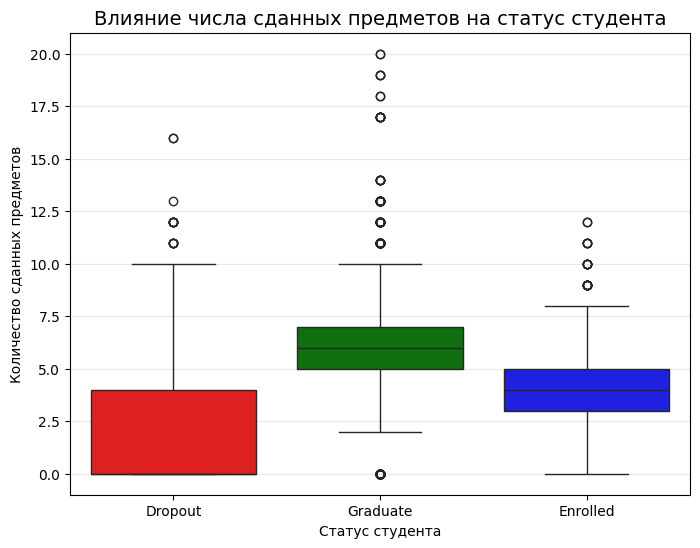

In [23]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Target', y='Curricular units 2nd sem (approved)', palette= {'Dropout': 'red', 'Enrolled': 'blue', 'Graduate': 'green'})
plt.title('Влияние числа сданных предметов на статус студента', fontsize=14)
plt.xlabel('Статус студента')
plt.ylabel('Количество сданных предметов')
plt.grid(axis='y', alpha=0.3)
plt.show()

В данном случае видим, фактически не существует студетнов, которые сдали бы менее 3 предментов за 2 семестр и остались бы в университете. В среднем студенту необходимо сдавать 6 предметов чтобы спокойно держаться на плаву. 

Отметим, что студенты, находящиеся в процессе обучения, имеют меньшее количество сданных предментов. Тут всё просто - скорее всего не было пересдач или по некоторым предментам ещё не закончилась аттестация. 

### Средний балл по предметам и его влияение на статус

C:\Users\artem.moshenko\AppData\Local\Temp\ipykernel_26132\1222966818.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target', y='Curricular units 2nd sem (grade)', palette={'Dropout': 'red', 'Enrolled': 'blue', 'Graduate': 'green'})


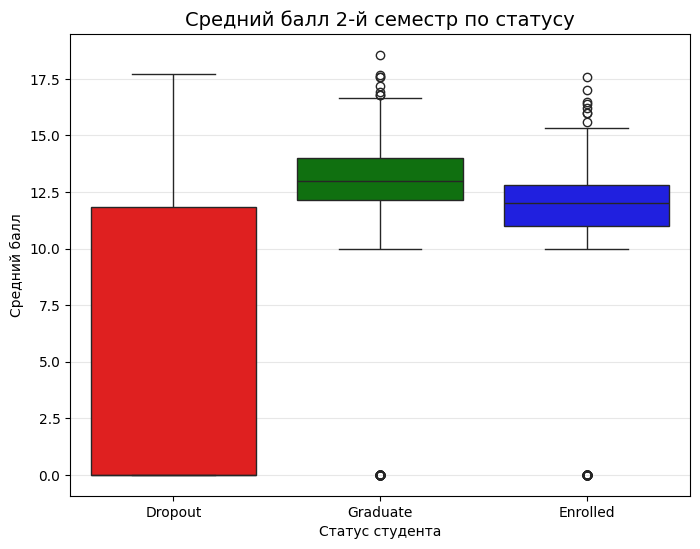

In [24]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Target', y='Curricular units 2nd sem (grade)', palette={'Dropout': 'red', 'Enrolled': 'blue', 'Graduate': 'green'})
plt.title('Средний балл 2-й семестр по статусу', fontsize=14)
plt.xlabel('Статус студента')
plt.ylabel('Средний балл')
plt.grid(axis='y', alpha=0.3)
plt.show()

По данному графику можем сделать достаточно простой вывод - студенты с оценкой ниже 12 всегда отчисляются, если проходят обучение. Конечно, видим несколько выбросов, студенты у которых по нулям но они выпустились или продолжают учиться. Но это либо сбой в системе, либо какие-то дополнительные условия.

Можно посмотреть на этих людей

In [25]:
special_students = df[(df['Curricular units 2nd sem (grade)'] == 0) & (df['Target'] != 'Dropout')].copy()

In [26]:
special_students

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Target_num
20,1,1,3,171,1,1,122.0,1,1,1,...,0,0,0,0.0,0,11.1,0.6,2.02,Graduate,2
59,1,1,3,171,1,1,125.0,1,38,37,...,0,0,0,0.0,0,7.6,2.6,0.32,Enrolled,1
62,1,17,3,171,1,1,133.0,1,1,37,...,0,0,0,0.0,0,10.8,1.4,1.74,Enrolled,1
64,1,43,1,9070,1,1,116.0,1,1,1,...,6,6,0,0.0,0,12.7,3.7,-1.70,Enrolled,1
66,1,1,3,171,1,1,139.0,1,19,19,...,0,0,0,0.0,0,10.8,1.4,1.74,Graduate,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4291,1,1,1,171,1,1,137.0,1,1,38,...,0,0,0,0.0,0,15.5,2.8,-4.06,Graduate,2
4353,1,1,1,171,1,1,141.0,1,3,1,...,0,0,0,0.0,0,12.4,0.5,1.79,Graduate,2
4365,1,1,2,171,1,1,117.0,1,38,38,...,0,0,0,0.0,0,7.6,2.6,0.32,Graduate,2
4370,1,1,3,171,1,1,137.0,1,1,3,...,0,0,0,0.0,0,12.7,3.7,-1.70,Graduate,2


Оказывается, что таких людей 143 человека и это явно аномалия. Вероятно они сдали позже или находятся в академическом отпуске

### Влияние возраста на обучение

colors = {'Dropout': 'red', 'Enrolled': 'blue', 'Graduate': 'green'}

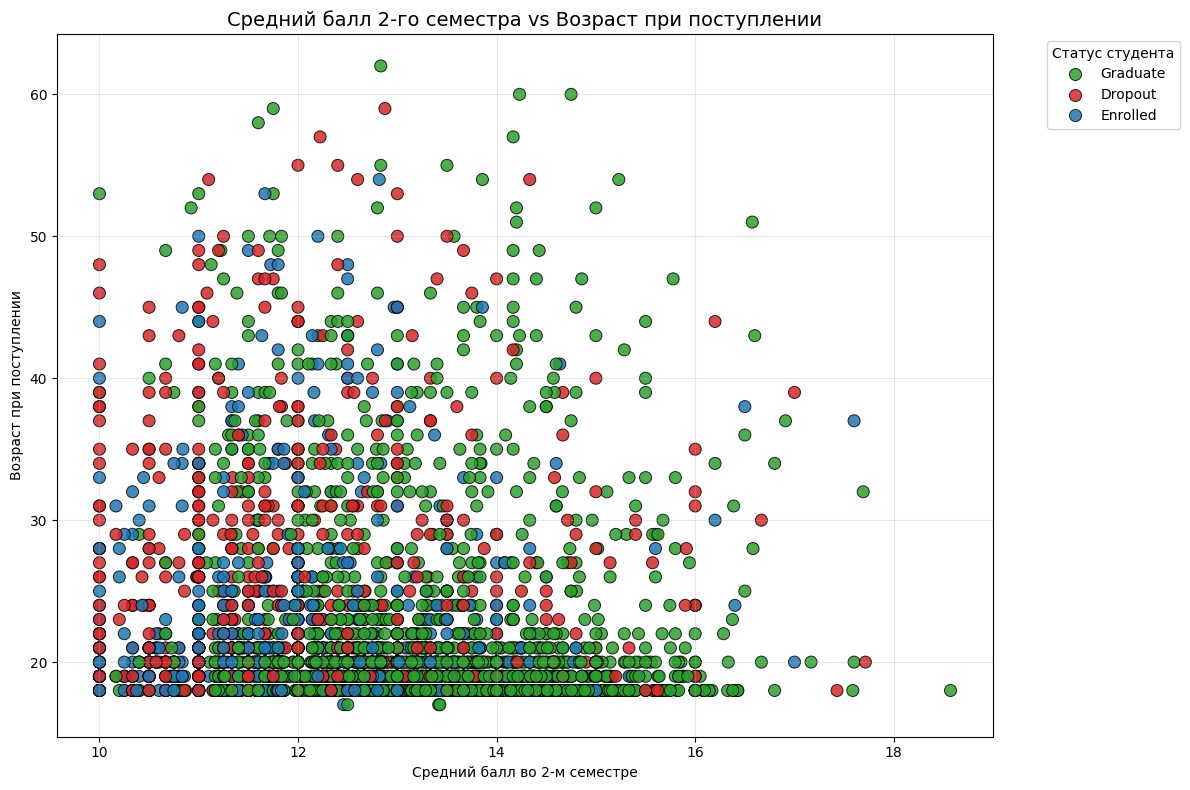

In [27]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df[df['Curricular units 2nd sem (grade)'] > 0],
    x='Curricular units 2nd sem (grade)',
    y='Age at enrollment',
    hue='Target',
    palette=colors,
    s=75,
    alpha=0.85,
    edgecolor='black'
)

plt.title('Средний балл 2-го семестра vs Возраст при поступлении', fontsize=14)
plt.xlabel('Средний балл во 2-м семестре')
plt.ylabel('Возраст при поступлении')
plt.legend(title='Статус студента', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Во-первых, мы убрали "нулевых" студентов, чтобы аномалии нам не мешались.

Во-вторых, мы видим, что количество отчислившихся студентов повышается при увеличении возраста и снижении среднего балла. 

### Средний балл 2ого семестра  вразных возрастных группах 

In [28]:
df['Age Group'] = pd.cut(df['Age at enrollment'], 
                         bins=[17, 20, 23, 26, 30, 40, 70],
                         labels=['18-19', '20-22', '23-25', '26-29', '30-39', '40+'])

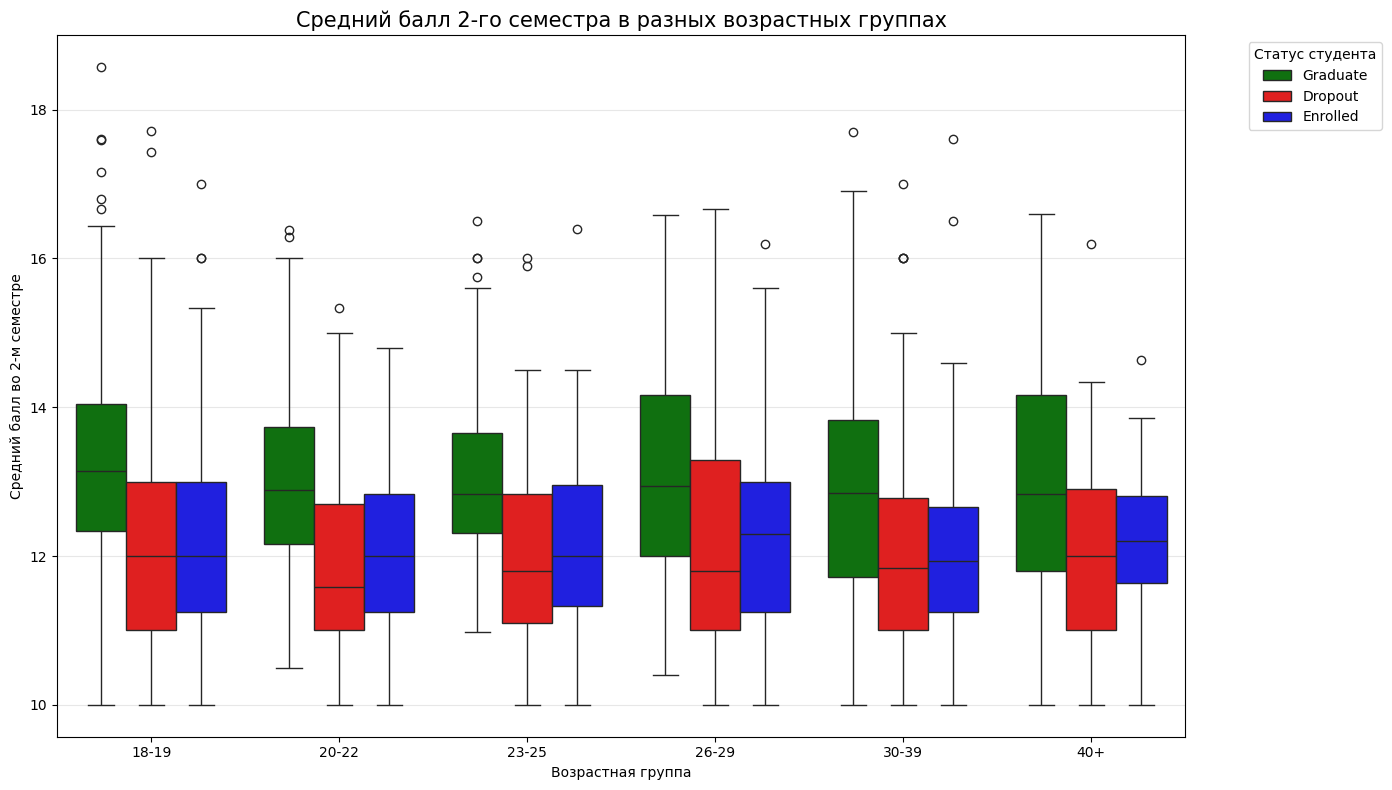

In [29]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df[df['Curricular units 2nd sem (grade)'] > 0], 
            x='Age Group', 
            y='Curricular units 2nd sem (grade)', 
            hue='Target',
            palette={'Dropout': 'red', 'Enrolled': 'blue', 'Graduate': 'green'})

plt.title('Средний балл 2-го семестра в разных возрастных группах', fontsize=15)
plt.xlabel('Возрастная группа')
plt.ylabel('Средний балл во 2-м семестре')
plt.legend(title='Статус студента', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

А теперь мы посмотрели на стеднов, которые участся или уже выпустились в разрезе различных возрастных групп. И мы видим, что, на самом деле, большой разницы между возрастом студентов нет. Но люди 18-19 лет более склонны учиться "идеально", потому что у них нет другой занятости.

Зато, можем сказать, что если человек в возрасте обучается, то его средняя ничем не хуже, чем у более молодых коллег студентов

И тут мы видим, что оценивание в датасете, который мы взяли, относится к Португальской системе, где баллы ставят от 10 (неудовлетворительно) до 20 (отлично)

### Направления  снаибольшим количеством отчислившихся

Для того, чтобы понять, какие направления являются самыми сложными, обратимся к документации датасета. В ячейке "Course" нам даны коды направлений. При этом, в документации, каждый код описан. Итого получаем вот такой словарь course_names:

In [30]:
course_names = {
    33: 'Biofuel Production Technologies',
    171: 'Animation and Multimedia Design',
    9003: 'Agronomy',
    9119: 'Informatics Engineering',
    9130: 'Equinculture',
    9147: 'Management',
    9238: 'Social Service',
    9254: 'Tourism',
    9500: 'Nursing',
    9556: 'Oral Hygiene',
    9670: 'Advertising and Marketing Management',
    9773: 'Journalism and Communication',
    9853: 'Basic Education',
    9991: 'Management (evening)',
    9085: 'Veterinary Nursing',
    9070: 'Communication Design',
    8014: 'Social Service (evening)'
}

Выявим 10 самых сложных направлений. Для этого посчитаем процент отчисления, отсортируем по убыванию и построим график

In [31]:
count_by_coure = df[df['Target'] == 'Dropout'].groupby('Course').size()

In [32]:
count_by_coure

Course
33        8
171      82
8014     71
9003     86
9070     51
9085     90
9119     92
9130     78
9147    134
9238     65
9254     96
9500    118
9556     33
9670     95
9773    101
9853     85
9991    136
dtype: int64

In [34]:
count_sort_value = df.groupby('Course').size().sort_values(ascending=False)

In [35]:
count_sort_value

Course
9500    766
9147    380
9238    355
9085    337
9773    331
9991    268
9670    268
9254    252
9070    226
8014    215
171     215
9003    210
9853    192
9119    170
9130    141
9556     86
33       12
dtype: int64

In [36]:
percentage_drop = count_by_coure / count_sort_value

In [37]:
percentage_drop = percentage_drop.sort_values(ascending=False)

In [38]:
max_10 = percentage_drop.head(10).reset_index()

In [39]:
max_10['Course_Name'] = max_10['Course'].map(course_names)

C:\Users\artem.moshenko\AppData\Local\Temp\ipykernel_26132\165510712.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=max_10, x='Course_Name', y=0, palette='Reds_r')


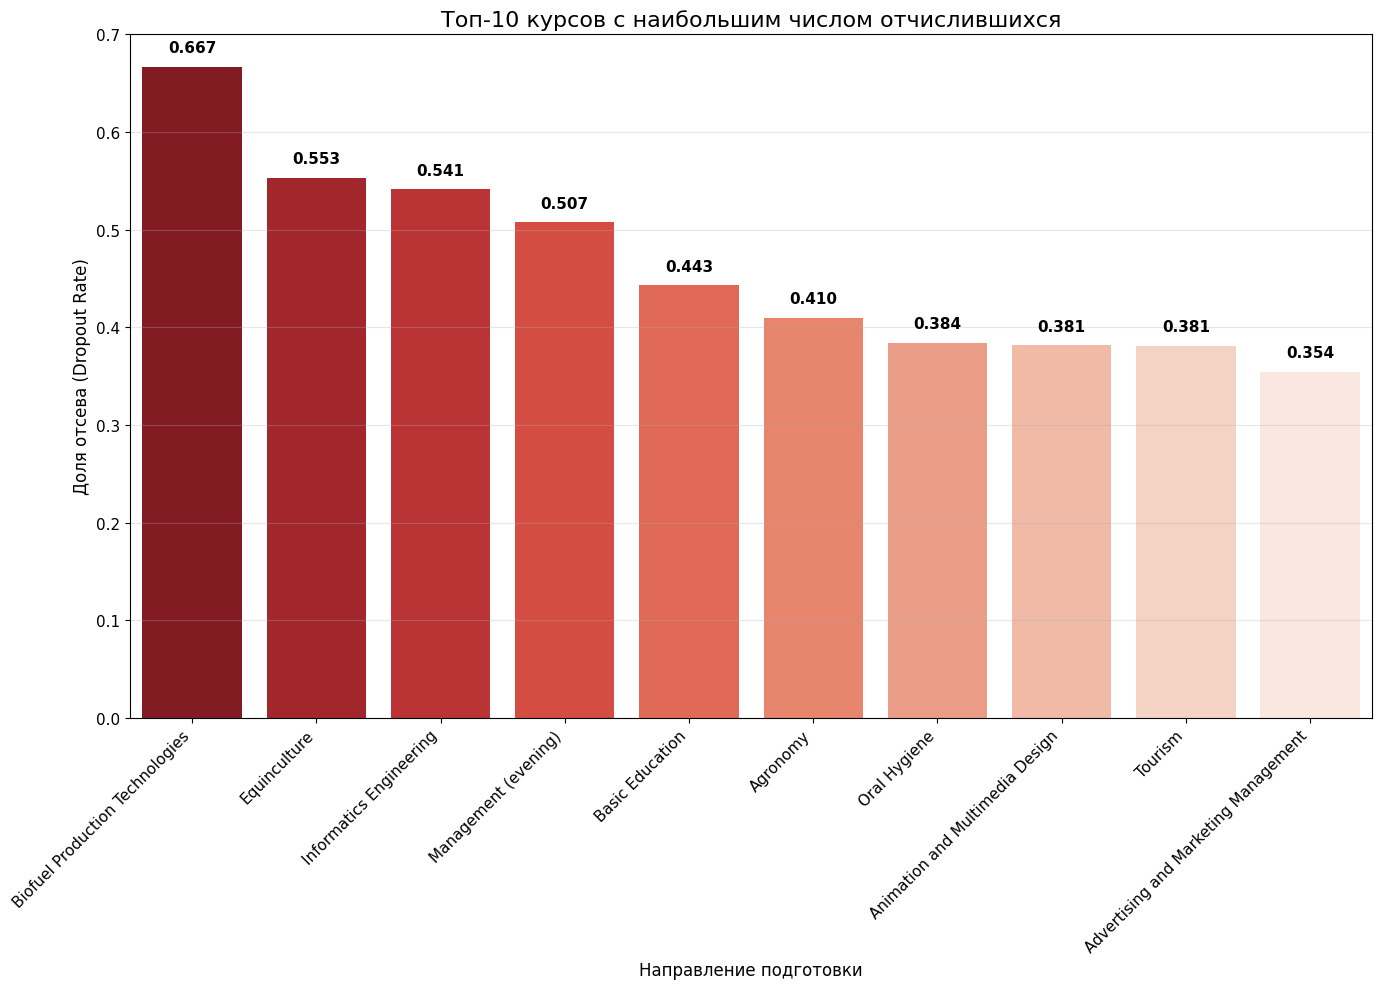

In [40]:
plt.figure(figsize=(14, 10))
sns.barplot(data=max_10, x='Course_Name', y=0, palette='Reds_r')

plt.title('Топ-10 курсов с наибольшим числом отчислившихся', fontsize=16)
plt.xlabel('Направление подготовки', fontsize=12)
plt.ylabel('Доля отсева (Dropout Rate)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)


for i, v in enumerate(max_10[0]):
    plt.text(i, v + 0.015, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Как мы видим, направления подготовки "Технологии производства биотоплива" является уверенным лидером по числу отчислившихся. Также больше половины потока уходят с программ "Коневодство" и "Инженерия информатики" и "Менеджмент (вечернее)". И тут заметим, что все направления, кроме менеджмента, имеют достаточно узкую направленность. А менеджмент - вечерний формати обучения. Если вспомнить график, на котором явно прослеживалась тенденция, что в вечернее время учится большее количество взрослых людей, а взрослые люди отчисляются чаще - можем сделать предположение, что направление не является очень сложным, просто люди уходят по своим обстоятельствам.

### Анализ категориальных признаков

In [19]:
df.columns = df.columns.str.strip()

В нашем датасете отдельно присутствуют категариальные признаки, которорые мы можем рассмотреть отдельно. Для того, чтобы в дальнейшем нам самим было проще понимать, какой признак что означает, создадим переменную *box_graph_names* и запишем в неё переводы наших признаков.

In [20]:
box_graph_names = [
    ('Gender', 'Пол'),
    ('Scholarship holder', 'Наличие стипендии'),
    ('Debtor', 'Наличие кредитных долгов'),
    ('Tuition fees up to date', 'Оплата обучения вовремя'),
    ('Displaced', 'Переезд из другого региона'),
    ('Daytime/evening attendance', 'Форма обучения')
]

Как мы видим, перед нами 6 категариальных признаков: пол; наличие стипендии; наличие кредитных долгов; оплата обучения вовремя; переезд из другого региаона; форма обучения. Теперь нам необходимо понять, в каких случаях что означает 0, что означает 1. Создадим переменную *box_label_names* и запишем в неё смысл для каждого бинарного значения.

In [21]:
box_label_names = {
    'Gender': {0: 'Женский', 1: 'Мужской'},
    'Scholarship holder': {0: 'Нет', 1: 'Есть'},
    'Debtor': {0: 'Нет', 1: 'Есть'},
    'Tuition fees up to date': {0: 'Просрочка', 1: 'Вовремя'},
    'Displaced': {0: 'Нет', 1: 'Да'},
    'Daytime/evening attendance': {0: 'Вечернее', 1: 'Дневное'}
}

Определимся с тем же цветом, которым мы пользовались ранее

In [22]:
colors = {'Dropout': 'red', 'Enrolled': 'blue', 'Graduate': 'green'}

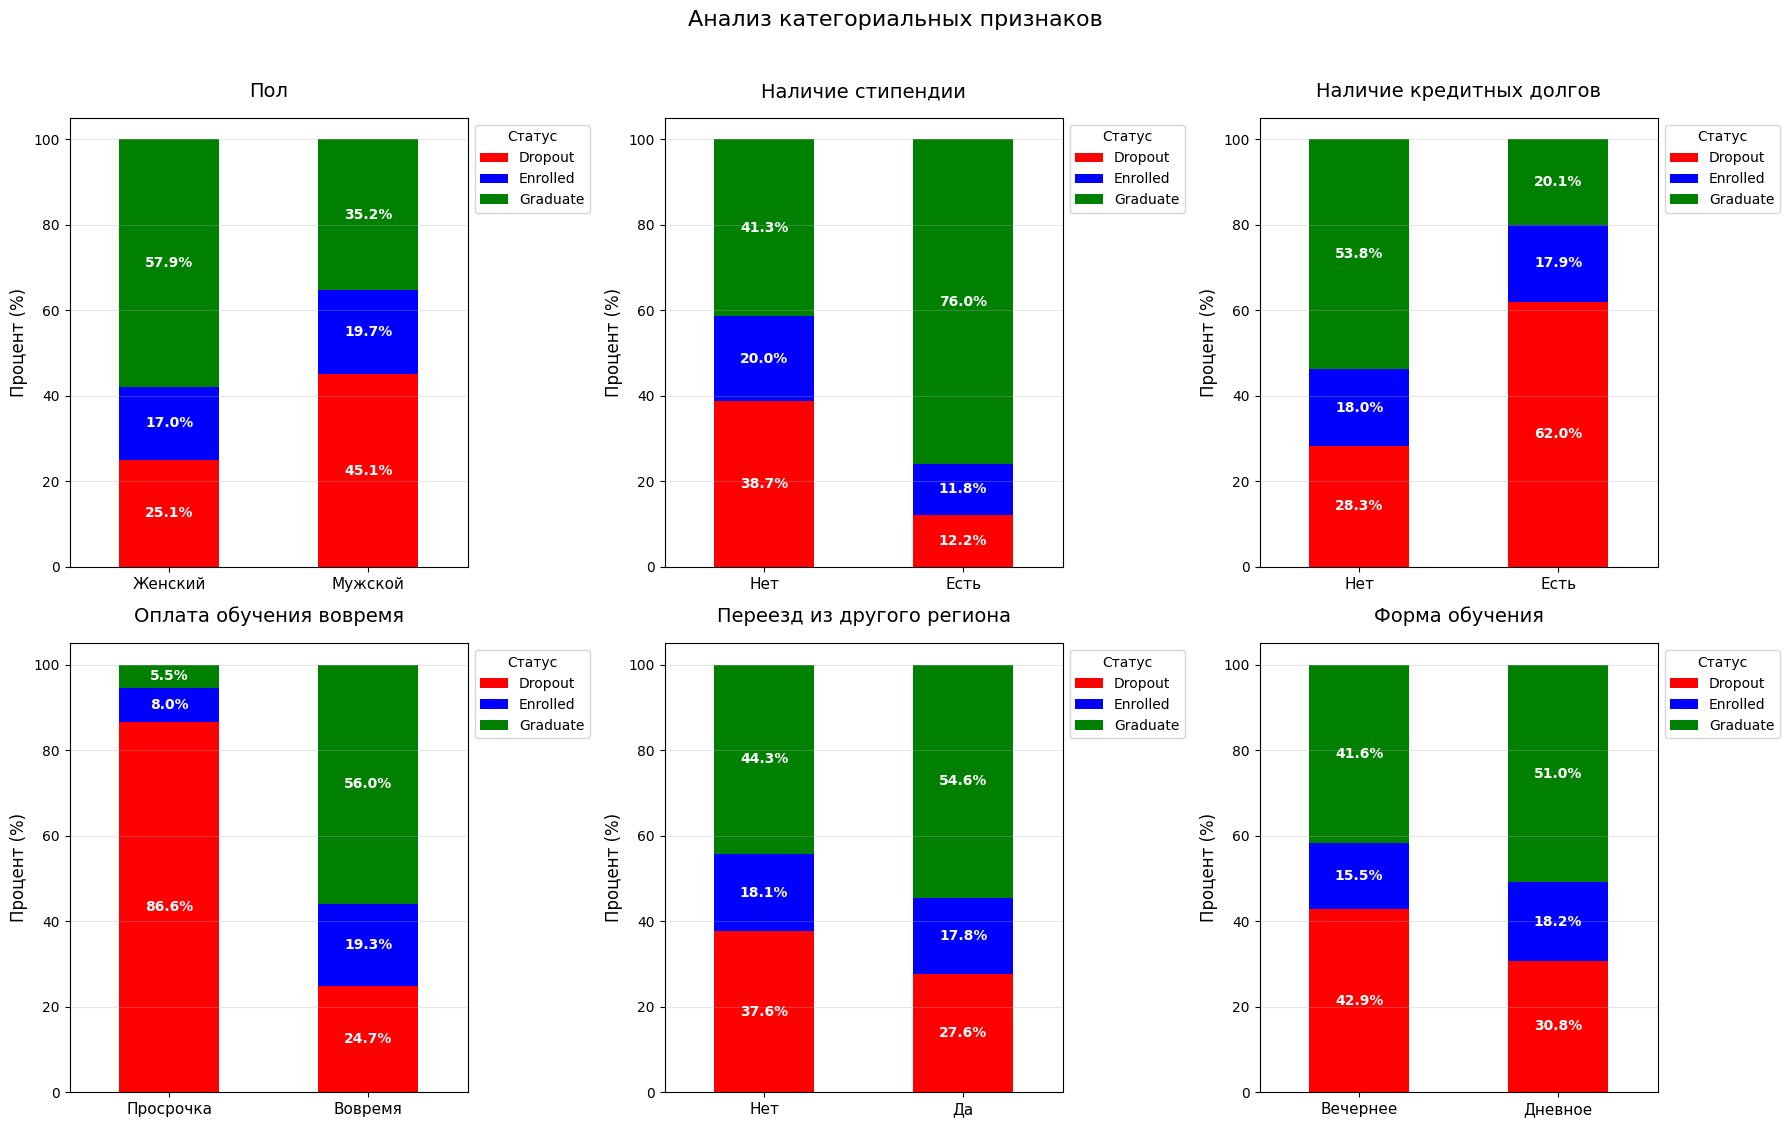

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()

for i, (col, title) in enumerate(box_graph_names):
    
    graph = pd.crosstab(df[col], df['Target'], normalize='index') * 100
    graph.plot(kind='bar', stacked=True, color=[colors.get(c, 'gray') for c in graph.columns], ax=axes[i])
    
    axes[i].set_title(title, fontsize=14, pad=15)
    axes[i].set_ylabel('Процент (%)', fontsize=12)
    axes[i].set_xlabel('')
    
    axes[i].set_xticklabels([box_label_names[col].get(x, x) for x in graph.index], rotation=0, fontsize=11)
    
    axes[i].legend(title='Статус', bbox_to_anchor=(1, 1))
    axes[i].grid(axis='y', alpha=0.3)
    
    for p in axes[i].patches:
        width, height = p.get_width(), p.get_height()
        if height > 4:
            x, y = p.get_xy()
            axes[i].text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center', fontsize=10, color='white', fontweight='bold')

plt.suptitle('Анализ категориальных признаков', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

Мы взяли 6 категариальных признаков и разбили их по нашим трём статусам: отчислился, обучается и выпустился. Видим ряд закономерностей.

Например, среди отчислившихся в 2 раза больше мужчин, чем женщин. Дюди, которые приехали из другого региона, намного реже покидают вуз (при этом на текущий момент их гораздо меньше чем было раньше). Кредитные долги - очень весомый показатель для предположения, что человек отчилится. Также это работает и для просрочек по оплате обучения. На вечернеей форме обучения люди отчисляются чуть больше и выпускаются успешно реже. А переезд из другого региона не сильно, но положительно влияет на судьбу студента.

### Влияние финансовой нагрузки на отчисление в зависимости от возраста студента

Для того, чтобы посмотроить график, подготовим необходимые данные:

In [23]:
df['is_adult_learner'] = (df['Age at enrollment'] >= 23).astype(int) # создаем категориальный признак, который определяет, больше ли или меньше студенту лет, чем 23 года
df['financial_state'] = df['Debtor'] + (1 - df['Tuition fees up to date']) # текущее финансовое состояние студент, вычитаем из дебиторки факты просрочек
df['is_dropout'] = (df['Target'] == 'Dropout').astype(int) # подбиваем к таргету 

И теперь группируем интересующие нас показатели (финансовое состояние студента, его принадлежность к группе возрастом ниже или выше 23 лет)

In [ ]:
plot_df = df.groupby(['financial_state', 'is_adult_learner'])['is_dropout'].mean().reset_index()

In [29]:
plot_df['Возрастная группа'] = plot_df['is_adult_learner'].map({ # отрисовывем легенду на нашем графике
    0: 'Молодые (< 23 года)', 
    1: 'Взрослые (>= 23 года)'
})

И теперь строим график, отслеживая, что все цвета отображены корректны, легенды находятся на своих местах

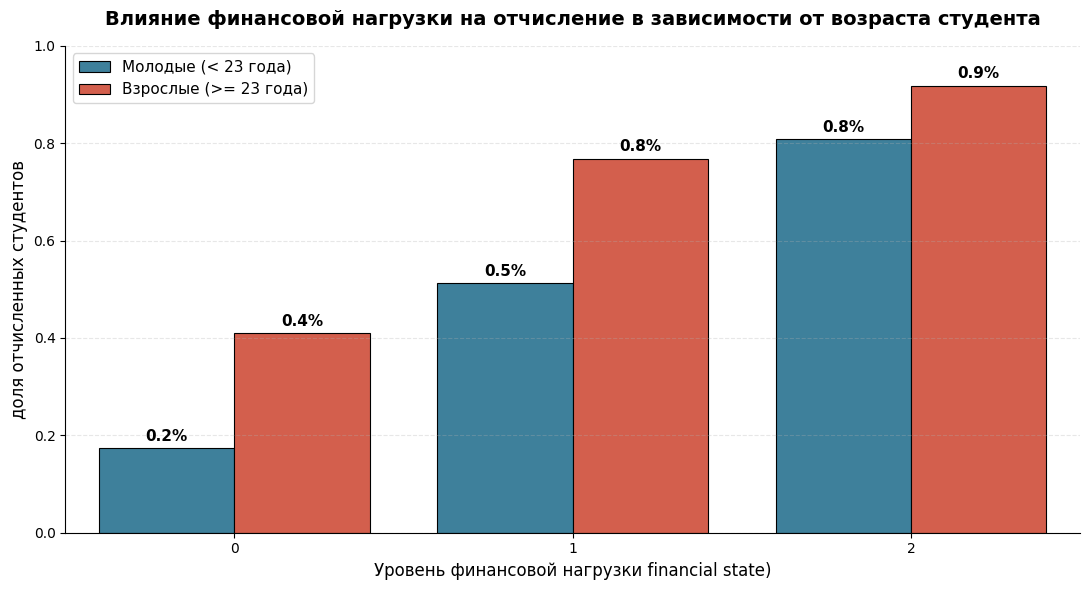

In [26]:
plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=plot_df, 
    x='financial_state', 
    y='is_dropout', 
    hue='Возрастная группа',
    palette=['#2E86AB', '#E94F37'],
    edgecolor='black',
    linewidth=0.8
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=3, fontsize=11, fontweight='bold')

plt.title('Влияние финансовой нагрузки на отчисление в зависимости от возраста студента', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Уровень финансовой нагрузки financial state)', fontsize=12)
plt.ylabel('доля отчисленных студентов', fontsize=12)
plt.ylim(0, 1)
plt.legend(title='', fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')

sns.despine()
plt.tight_layout()
plt.show()

### Влияние стипендии для студентов первого поколения на успешность обучения

Для данного графика соберём из документации коды направлений, чтобы в дальнейшем была возможность проверять, входит ли образование родителей или нет в этот список (информацию берём из доки датасета)

In [ ]:
higher_edu = [2, 3, 4, 5, 6, 40, 41, 42, 43, 44]

Теперь считаем вхождение родиетелей (папы и мамы) и делаем новый категариальный признак под названием "first_gen"

In [ ]:
df['first_gen'] = ((~df["Mother's qualification"].isin(higher_edu)) & (~df["Father's qualification"].isin(higher_edu))).astype(int)

Добавляем обработку по таргету отчислившихся в новый категариальный признак

In [ ]:
df['is_dropout'] = (df['Target'] == 'Dropout').astype(int)

Подготавливаем данные для дальнейшего построения графика: работаем с отчисленными и прописываем значения для каждого категариального признака

In [ ]:
plot_df = df.groupby(['first_gen', 'Scholarship holder'])['is_dropout'].mean().reset_index()
plot_df['first_gen_label'] = plot_df['first_gen'].map({0: 'Не first-gen', 1: 'First-gen'})
plot_df['stip_label'] = plot_df['Scholarship holder'].map({0: 'Без стипендии', 1: 'Со стипендией'})

Строим график

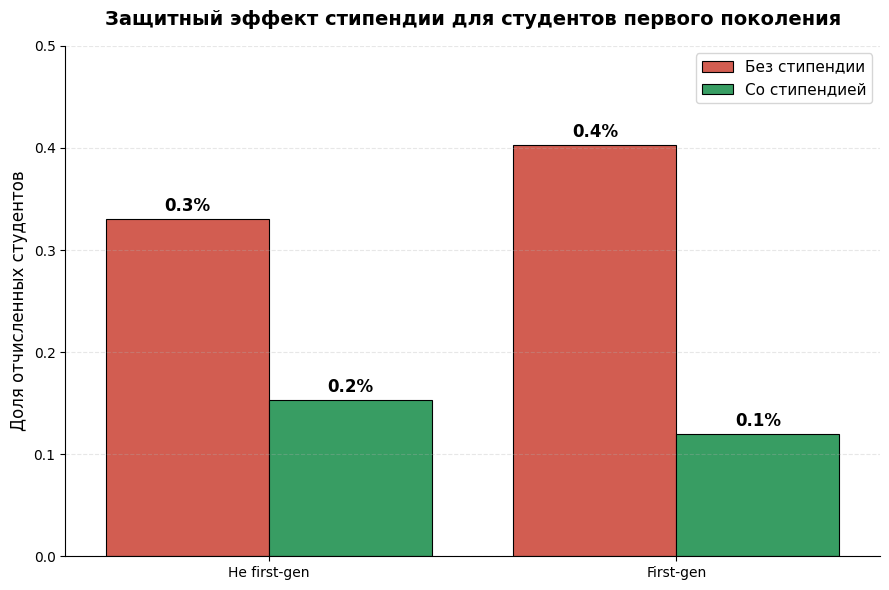

In [50]:
plt.figure(figsize=(9, 6))
ax = sns.barplot(
    data=plot_df, 
    x='first_gen_label', 
    y='is_dropout', 
    hue='stip_label',
    palette=['#E74C3C', '#27AE60'],
    edgecolor='black',
    linewidth=0.8
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=3, fontsize=12, fontweight='bold')

plt.title('Защитный эффект стипендии для студентов первого поколения', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('')
plt.ylabel('Доля отчисленных студентов', fontsize=12)
plt.ylim(0, 0.5)
plt.legend(title='', fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show()

## Формирование гиотез на основе проведённого EDA

### Гипотеза 1. Количество сданных предментов для успешного продолжения обучения

**Формулировка:**  
Студенты, которые во втором семестре сдают **менее 4 предметов** (`Curricular units 2nd sem (approved) < 4`), имеют **значительно более высокую вероятность отсева** по сравнению со студентами, сдавшими 4+ предметов.

**Обоснование из EDA:**
- Самая высокая корреляция с целевой переменной среди всех признаков (**+0,624**).
- На boxplot наблюдается чёткий разрыв: медиана у проходящих обучение 7-8 сданных предметов, а у отчисленных = 2-3.
- Успеваемость 1-го и 2-го семестра сильно коррелирует между собой (r = 0.90).

В ходе проведения EDA мы в первую очередь считали корреляцию всех признаков с целевой переменной (Target). Самая сильная связь оказалась у признака «Количество сданных предметов во 2-м семестре» - корреляция +0,624. Это самый высокий показатель среди всех 36 признаков.

Дальше  строили boxplot, scatterplot. На графиках выявили чёткое разделение:

Студенты, которые успешно выпустились, в среднем сдавали 7–8 предметов за второй семестр.
Те, кого отчислили, сдавали в среднем всего 2-3 предмета.

Проверили различные пороги, увидели, что именно 4 сданных предмета — это критическая граница, после которой шансы на отчисление резко возрастают. То есть, кто сдает меньше 4, почти всегда попадают в группу отчисленных.

Дополнительно заметили, что успеваемость между 1-м и 2-м семестром очень стабильная (корреляция = 0,9). То есть, если студент плохо учится уже в первом семестре - почти всегда так же плохо продолжает и во втором.

### Гипотеза 2. Влияние количества долгов и финансового состояния студента на вероятность его отчисления 

**Формулировка:**  
Наличие долгов (`Debtor = 1`) и/или просрочка оплаты обучения (`Tuition fees up to date = 0`) являются **независимыми** значимыми предикторами отсева, даже при контроле за академической успеваемостью.

**Обоснование из EDA:**
- Сильные корреляции: Debtor = **–0,241**, Tuition fees up to date = **+0.41**.
- В группе Debtor доля Dropout достигает = 62%, среди студентов с просрочкой оплаты до 87%.
- Эти факторы слабо коррелируют с успеваемостью.

При расчёте корреляции мы увидели, что с отвевом связаны:

Debtor (есть долги) - корреляция -0,241
Tuition fees up to date (оплата вовремя) - корреляция +0,410

Это одни из самых высоких корреляций после академической успеваемости.

Из stacked bar charts посчитали проценты:
Среди студентов, у которых есть долги (Debtor = 1), 62% отчисляются.
Среди тех, кто не платит вовремя за обучение, доля отсева доходит до 87%.

Важно, что эти финансовые проблемы слабо коррелируют с оценками. То есть даже студенты с нормальной успеваемостью, но с долгами или просрочками, часто отчисляются.

Далее проверили, влияет ли это независимо от возраста и оценок - да, влияние остаётся сильным. Получается, что финансовые трудности -  это отдельная, независимая причина отсева.

### Гипотеза 3. Влияние возраста студента при поступлении

**Формулировка:**  
Студенты, поступившие в университет в возрасте **24 года и старше** (`Age at enrollment ≥ 24`), имеют статистически значимо более высокий риск отсева по сравнению со студентами 18–22 лет, даже при сопоставимой успеваемости.

**Обоснование из EDA:**
- Отрицательная корреляция возраста с целевой переменной (**–0,243**).
- Средний возраст: Dropout - **26,1 года**, Graduate - **21,8 лет**.
- На scatterplot после 23–24 лет резко растёт доля отчисленных студентов.

В данной гипотезе наиболее интересным признаком является возраст студента при поступлении (Age at enrollment). Его корреляция с Target -0,243, что является одним из самых сильных отрицательных корреляций.

Средние значения возраста по группам:

Dropout (отчисленные) - 26,1 года
Enrolled (продолжают учиться) - 22,4 лет
Graduate (выпускники) - 21,8 года

Разница почти 4,3 года.

На boxplot и scatterplot после 23–24 лет растёт количество отчисленных в несколько раз. Даже среди студентов с примерно одинаковыми оценками старшие студенты отсеиваются чаще.

Это логично: у взрослых студентов обычно больше внешних факторов - работа, семья, дети, финансовые обязательства, из-за которых сложнее учиться.

## Гипотеза 4. Защитный эффект стипендии для студентов первого поколения

**Формулировка:**

Стипендия оказывает значительно более сильный защитный эффект для студентов первого поколения (`first_gen = 1`), чем для студентов, чьи родители имеют высшее образование. Наличие стипендии снижает риск отчисления у студентов первого поколения почти в три раза.

**Обоснование из EDA:**

- Среди студентов первого поколения (`first_gen = 1`) без стипендии доля отчислений составляет **40,3%**, а при наличии стипендии — **12,0%**.
- Среди студентов, не являющихся первым поколением, разница менее выражена: **33,0%** без стипендии против **15,3%** со стипендией.
- Стипендия снижает риск отчисления у first-gen студентов на **28,3 п.п.**, тогда как у остальных студентов — на **17,7 п.п.**

В данной гипотезе используется новый признак `first_gen`, отражающий, является ли студент первым в семье, кто получает высшее образование. 

Результаты показывают, что финансовая поддержка в виде стипендии особенно важна именно для студентов из семей с более низким образовательным капиталом. Для них стипендия выступает не просто как дополнительная мотивация, а как значимый фактор, существенно снижающий вероятность отчисления.

## Гипотеза 5. Влияние финансовой нагрузки на взрослых студентов

**Формулировка:**

Финансовая нагрузка (`financial_state`) оказывает более сильное негативное влияние на вероятность отчисления у взрослых студентов (`is_adult_learner = 1`), чем у студентов младше 23 лет. Взрослые студенты демонстрируют существенно более высокий риск отчисления даже при умеренном уровне финансовых трудностей.

**Обоснование из EDA:**

- При отсутствии финансовой нагрузки (`financial_state = 0`) доля отчислений среди взрослых студентов составляет **41,1%**, тогда как среди молодых — **17,4%**.
- При среднем уровне финансовой нагрузки (`financial_state = 1`) разрыв сохраняется: **76,8%** у взрослых против **51,2%** у молодых.
- При высокой финансовой нагрузке (`financial_state = 2`) риск отчисления высок в обеих группах, однако у взрослых он достигает **91,8%**.

В данной гипотезе рассматривается взаимодействие двух признаков: `financial_state` (уровень финансовой нагрузки) и `is_adult_learner` (принадлежность к группе взрослых студентов).

Результаты показывают, что взрослые студенты значительно более уязвимы к финансовым трудностям. Даже при относительно низком уровне финансовой нагрузки их риск отчисления более чем в два раза выше, чем у молодых студентов. Это может быть связано с тем, что у взрослых обучающихся обычно больше внешних финансовых обязательств и меньше возможностей для манёвра в случае возникновения долгов или просрочек по оплате обучения.
